# Pipeline Simulation

End-to-end simulation of the Nicole-owned pipeline (BOCD + recommender +
response_logic) over multi-day synthetic user trajectories. Pulls per-user
β values from Kaitlyn's `ml.data.synthetic_generator`, drives daily check-ins
through the **real** `process_checkin` against an in-memory SQLite DB, and
plots the resulting trajectories.

What this notebook proves that the unit tests don't:
- The orchestration layer (`process_checkin`, `_apply_checkin_actions`,
  `run_reevaluation`) actually composes — descriptor shapes match, DB writes
  land in the right tables.
- BOCD detects regime changes against synthetic noise (not just the clean
  step-function inputs from the unit tests).
- The recommender escalates / de-escalates over realistic timeframes and
  reacts to drift events without thrashing.
- Projection bias accumulates correctly when actual durations exceed planned.

CF / probe calls are mocked: we update `user.beta_proxy` with a slow EMA of
the rolling completion rate, simulating what the linear probe should learn.

In [1]:
import sys
import os
from datetime import datetime, timedelta, timezone, date
from types import SimpleNamespace
from unittest.mock import patch
import uuid

# Backend config requires these at import time (validated by pydantic-settings).
# Use placeholder values — we never actually hit Postgres or Supabase here.
os.environ.setdefault('DATABASE_URL', 'sqlite:///:memory:')
os.environ.setdefault('SUPABASE_URL', 'https://placeholder.supabase.co')
os.environ.setdefault('SUPABASE_ANON_KEY', 'placeholder')
os.environ.setdefault('SUPABASE_SERVICE_KEY', 'placeholder')
os.environ.setdefault('SUPABASE_JWT_SECRET', 'placeholder-secret-32-chars-minimum!!')

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker

from backend.database import Base
from backend.models import db as models
from backend import response_logic
from backend.response_logic import (
    process_checkin, run_reevaluation, on_device_change,
)
from backend.ml.bocd import load_detector
from ml.data.synthetic_generator import generate_dataset

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

# --- Real CF/probe via ml.inference.inference_api -----------------------------
# We isolate the user-state table in a temp directory so this exploratory
# simulation cannot touch production user embeddings on disk. The model
# weights, probe, and feature stats are read-only — copy them in.
import shutil
import tempfile
from pathlib import Path

from ml.inference.inference_api import (
    TaskFeatures,
    configure_artifact_dir,
    get_user_state,
    incremental_update_api,
    initialize_new_user,
)
from ml.training.pretrain import (
    CF_MODEL_FILE,
    DEFAULT_ARTIFACT_DIR,
    FEATURE_STATS_FILE,
    PROBE_FILE,
    USER_STATE_FILE,
)

_SIM_ARTIFACT_DIR = Path(tempfile.mkdtemp(prefix="ft_sim_"))
for fname in (CF_MODEL_FILE, PROBE_FILE, FEATURE_STATS_FILE, USER_STATE_FILE):
    shutil.copy2(Path(DEFAULT_ARTIFACT_DIR) / fname, _SIM_ARTIFACT_DIR / fname)
configure_artifact_dir(_SIM_ARTIFACT_DIR)
print(f"Simulation user-state isolated in {_SIM_ARTIFACT_DIR}")

_CATEGORY_TO_INDEX = {"academic": 0, "exercise": 1, "work": 2, "personal": 3}
_DEADLINE_TO_INDEX = {"today": 0, "this_week": 1, "none": 2}


Simulation user-state isolated in /tmp/ft_sim_gvpd3bhm


## In-memory DB harness

Stand up SQLite (no Postgres needed), create all tables from the SQLAlchemy
metadata, and define a couple of helpers: `make_user` builds a fresh user
row, `reset_db` wipes between scenarios.

We use `JSON` for `detector_state` instead of Postgres `JSONB`. SQLAlchemy's
JSONB type doesn't have a SQLite fallback, so we monkey-patch the column
type on the User model before `create_all`.

In [2]:
from sqlalchemy import JSON

# Swap JSONB → JSON for SQLite compatibility (does not affect production schema).
models.User.__table__.c.detector_state.type = JSON()

engine = create_engine('sqlite:///:memory:', echo=False)
Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)


def reset_db():
    """Drop all tables and recreate. Returns a fresh session."""
    Base.metadata.drop_all(engine)
    Base.metadata.create_all(engine)
    return Session()


def make_user(db, beta=0.70, email='test@x.com', current_device=0):
    """Insert a fresh user with a known starting beta."""
    u = models.User(
        id=uuid.uuid4(),
        email=email,
        beta_proxy=beta,
        proj_bias_score=0.0,
        current_device=current_device,
        streak=0,
        created_at=datetime(2026, 1, 1),  # arbitrary anchor
        embedding_id=initialize_new_user(),  # allocate a fresh CF user slot
    )
    db.add(u)
    db.commit()
    db.refresh(u)
    return u

## Time-controlled simulator

`simulate_day` is the workhorse. Each call:
1. Inserts a `Task` and `Checkin` row dated to the simulated day,
2. Patches `response_logic.datetime.now` so the BOCD daily-tick guard sees the
   right calendar day,
3. Calls the real `process_checkin`,
4. Applies the returned descriptors (mimicking what the router does in
   `_apply_checkin_actions`),
5. Updates a fake β estimate (slow EMA of rolling completion — the probe stand-in),
6. Triggers `run_reevaluation` if the descriptor flagged drift,
7. Returns a row of metrics for plotting.

In [3]:
BETA_PROBE_ALPHA = 0.05  # mock CF/probe: slow EMA toward rolling rate
BETA_FLOOR, BETA_CEIL = 0.30, 0.99


class FrozenDatetime(datetime):
    """datetime subclass whose .now() is class-frozen to ``_frozen``."""
    _frozen = datetime(2026, 1, 1)

    @classmethod
    def now(cls, tz=None):
        return cls._frozen.replace(tzinfo=tz) if tz else cls._frozen


def _rolling_rate(user_id, db, n_days=14):
    """Mock probe: completion rate over the last n_days."""
    rows = (
        db.query(models.Checkin)
        .filter(models.Checkin.user_id == user_id)
        .order_by(models.Checkin.checked_in_at.desc())
        .limit(n_days)
        .all()
    )
    if not rows:
        return None
    return float(np.mean([c.completed for c in rows]))


def _apply_actions(user, actions):
    """Mirror routers/checkins.py:_apply_checkin_actions without notification I/O."""
    if actions.proj_bias_update is not None:
        user.proj_bias_score = actions.proj_bias_update
    if actions.streak_set_to is not None:
        user.streak = actions.streak_set_to
    elif actions.streak_delta:
        user.streak = max(0, user.streak + actions.streak_delta)


def simulate_day(user, sim_date, completed, planned_duration, actual_duration, db,
                  difficulty=3, deadline_pressure='this_week'):
    """Run one day through the real pipeline; return a metrics row."""
    # 1. Build the Task and Checkin rows directly (we are bypassing the router).
    task = models.Task(
        user_id=user.id,
        name=f'task-{sim_date.isoformat()}',
        category='academic',
        difficulty=difficulty,
        deadline_pressure=deadline_pressure,
        planned_start=datetime.combine(sim_date, datetime.min.time()) + timedelta(hours=9),
        planned_duration=planned_duration,
    )
    db.add(task)
    db.flush()

    checkin_input = SimpleNamespace(
        completed=completed,
        actual_duration=actual_duration,
        failure_reason=None,
    )
    checkin = models.Checkin(
        task_id=task.id,
        user_id=user.id,
        completed=completed,
        actual_duration=actual_duration,
        checked_in_at=datetime.combine(sim_date, datetime.min.time()) + timedelta(hours=18),
    )
    db.add(checkin)
    db.flush()

    # 2. Freeze 'today' so BOCD ticks for the simulated calendar day.
    FrozenDatetime._frozen = datetime.combine(sim_date, datetime.min.time()) + timedelta(hours=20)
    with patch.object(response_logic, 'datetime', FrozenDatetime):
        actions = process_checkin(user, task, checkin_input, db)
        _apply_actions(user, actions)

        # 3. Real CF/probe: run an incremental update on the live outcome,
        #    then read the β proxy off the Ridge probe.
        days_until = max(0, (task.planned_start.date() - sim_date).days)
        feats = TaskFeatures(
            difficulty=(difficulty - 1) / 4.0,
            category_index=_CATEGORY_TO_INDEX[task.category],
            planned_duration_minutes=float(planned_duration),
            days_until_planned_start=int(days_until),
            deadline_pressure_index=_DEADLINE_TO_INDEX[deadline_pressure],
        )
        incremental_update_api(user.embedding_id, feats, completed)
        user.beta_proxy = get_user_state(user.embedding_id)

        # 4. Re-evaluate device on every check-in (mirrors the router).
        old_device = user.current_device
        result = run_reevaluation(user, db)
        device_changed = result.changed

    db.commit()

    detector = load_detector(user)
    return {
        'date': sim_date,
        'completed': completed,
        'planned_duration': planned_duration,
        'actual_duration': actual_duration or 0,
        'beta_proxy': user.beta_proxy,
        'proj_bias_score': user.proj_bias_score,
        'streak': user.streak,
        'current_device': user.current_device,
        'cp_score': detector.last_result()['changepoint_prob'],
        'drift_status': detector.drift_status,
        'expected_run_length': detector.last_result()['expected_run_length'],
        'bocd_ticked': actions.bocd_ticked,
        'device_changed': device_changed,
        'old_device': old_device,
    }

## Synthetic users from Kaitlyn's generator

We pull a population of synthetic users so β values land in the same
distribution Kaitlyn's CF model was trained against (`Beta(7, 3)`, mean ≈ 0.7).
We pick three: a high-β user, a mid-β user, and a low-β user, and use those
true β values to drive each scenario's daily completion probabilities.

In [4]:
ds = generate_dataset(num_users=50, tasks_per_user=10, seed=42)
betas = ds.betas
print(f'population β: mean={betas.mean():.3f}, std={betas.std():.3f}, '
      f'min={betas.min():.3f}, max={betas.max():.3f}')

# Pick three users by quantile.
low_user_beta = float(np.quantile(betas, 0.10))
mid_user_beta = float(np.quantile(betas, 0.50))
high_user_beta = float(np.quantile(betas, 0.90))
print(f'low={low_user_beta:.3f}  mid={mid_user_beta:.3f}  high={high_user_beta:.3f}')

population β: mean=0.707, std=0.129, min=0.361, max=0.942
low=0.538  mid=0.726  high=0.842


## Plotting helper

In [5]:
DEVICE_LABELS = ['L0 Salience', 'L1 Impl-Int', 'L2 Planning', 'L3 Stakes', 'L4 Lock']
DRIFT_COLORS = {
    'stable': '#e8e8e8',
    'potential': '#fff3b0',
    'confirmed_decline': '#f4a8a8',
    'confirmed_improvement': '#b0e0a8',
}


def plot_trajectory(rows, true_beta_series, title):
    days = np.arange(len(rows))
    completed = np.array([r['completed'] for r in rows])
    beta = np.array([r['beta_proxy'] for r in rows])
    pb = np.array([r['proj_bias_score'] for r in rows])
    cp = np.array([r['cp_score'] for r in rows])
    devices = np.array([r['current_device'] for r in rows])
    statuses = [r['drift_status'] for r in rows]
    device_changes = [i for i, r in enumerate(rows) if r['device_changed']]

    fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True,
                              gridspec_kw={'height_ratios': [1.4, 1, 1, 1]})

    # Row 1: completion outcomes + true vs estimated beta
    ax = axes[0]
    colors = ['#d04848' if c == 0 else ('#a0a0a0' if c == 0.5 else '#4caf50') for c in completed]
    ax.scatter(days, completed, c=colors, s=30, label='outcome', zorder=3)
    ax.plot(days, beta, color='C0', lw=1.6, label='β_proxy (estimated)')
    ax.plot(days, true_beta_series, color='C0', lw=1.0, ls='--', alpha=0.6, label='β true (drift)')
    ax.set_ylim(-0.1, 1.1)
    ax.set_ylabel('outcome / β')
    ax.set_title(title)
    ax.legend(loc='lower left', fontsize=8, ncol=3)

    # Row 2: projection bias
    ax = axes[1]
    ax.plot(days, pb, color='C2', lw=1.4)
    ax.axhline(0.3, color='gray', ls='--', lw=0.7, label='Level-2 trigger (>0.3)')
    ax.set_ylabel('proj_bias_score')
    ax.legend(loc='upper right', fontsize=8)

    # Row 3: cp_score + drift status band
    ax = axes[2]
    for i, s in enumerate(statuses):
        ax.axvspan(i - 0.5, i + 0.5, color=DRIFT_COLORS.get(s, '#fff'), alpha=0.7, lw=0)
    ax.plot(days, cp, color='C3', lw=1.4, label='P(r_t ≤ 3)')
    ax.axhline(0.5, color='gray', ls='--', lw=0.7)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('cp_score')
    ax.legend(loc='upper right', fontsize=8)

    # Row 4: device level + change markers
    ax = axes[3]
    ax.step(days, devices, where='post', color='C4', lw=1.5)
    for i in device_changes:
        ax.axvline(i, color='C4', alpha=0.4, lw=0.8)
    ax.set_yticks(range(5))
    ax.set_yticklabels(DEVICE_LABELS, fontsize=8)
    ax.set_ylim(-0.5, 4.5)
    ax.set_xlabel('day')
    ax.set_ylabel('device')

    plt.tight_layout()
    plt.show()

    # Print summary
    drift_events = (
        Session().bind.connect().execute(
            __import__('sqlalchemy').text('SELECT COUNT(*) FROM drift_events')
        ).scalar()
    )
    print(f'final β_proxy={beta[-1]:.3f}  proj_bias={pb[-1]:.3f}  '
          f'device={DEVICE_LABELS[devices[-1]]}  drift_status={statuses[-1]}')
    print(f'device changes during run: {len(device_changes)}')

## Scenario 1 — Stable high performer

True β stays at the 90th-percentile value across 40 days. Expected behavior:
- β_proxy climbs from 0.70 toward true β.
- BOCD never flags; drift_status stays `stable`.
- Device escalates from L0 → L1 → L3 → L4 as β_proxy crosses thresholds, then
  may de-escalate via the sustained-success path (≥0.90 for ≥2 weeks).

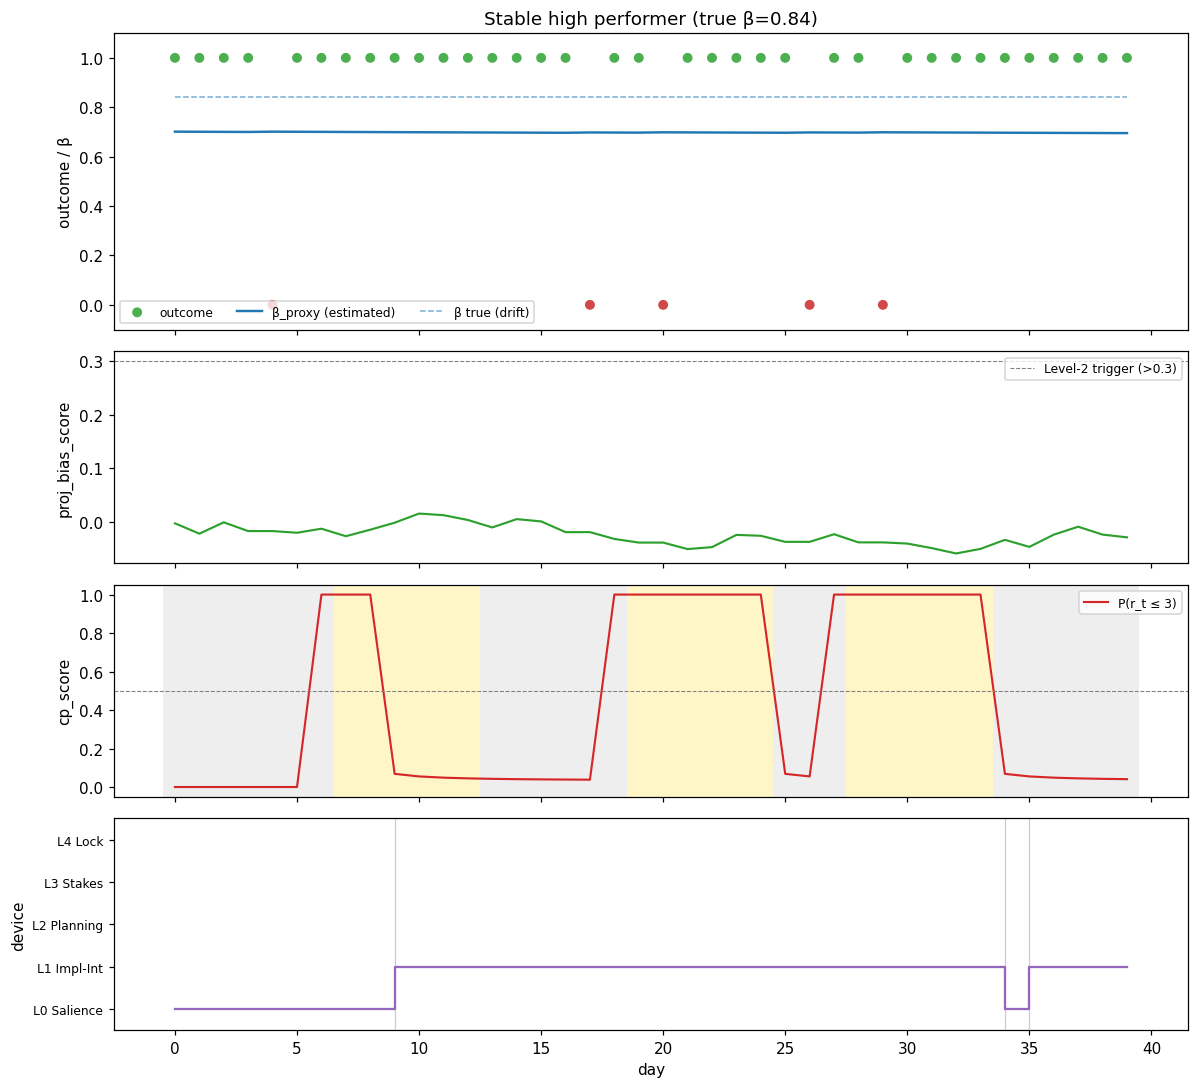

final β_proxy=0.695  proj_bias=-0.030  device=L1 Impl-Int  drift_status=stable
device changes during run: 3


In [6]:
db = reset_db()
user = make_user(db, beta=0.70, email='stable_high@x.com')

rng = np.random.default_rng(11)
N_DAYS = 40
true_beta = np.full(N_DAYS, high_user_beta)
rows = []
for d in range(N_DAYS):
    sim_date = date(2026, 1, 2) + timedelta(days=d)
    p = float(true_beta[d])
    completed = 1.0 if rng.random() < p else 0.0
    planned = 60
    actual = int(planned * rng.uniform(0.9, 1.1)) if completed > 0 else None
    rows.append(simulate_day(user, sim_date, completed, planned, actual, db))

plot_trajectory(rows, true_beta, f'Stable high performer (true β={high_user_beta:.2f})')

## Scenario 2 — Gradual decline followed by recovery

True β starts at 0.85 → drops to 0.30 over days 25–30 → recovers to 0.85 by
day 50. Expected behavior:
- BOCD: cp_score crosses 0.5 within ~5 days of the drop, drift_status
  transitions stable → potential → confirmed_decline.
- DriftEvent row written, recommender escalates.
- After recovery, drift_status either stays sticky at confirmed_decline (per
  current implementation) or another flag triggers confirmed_improvement.

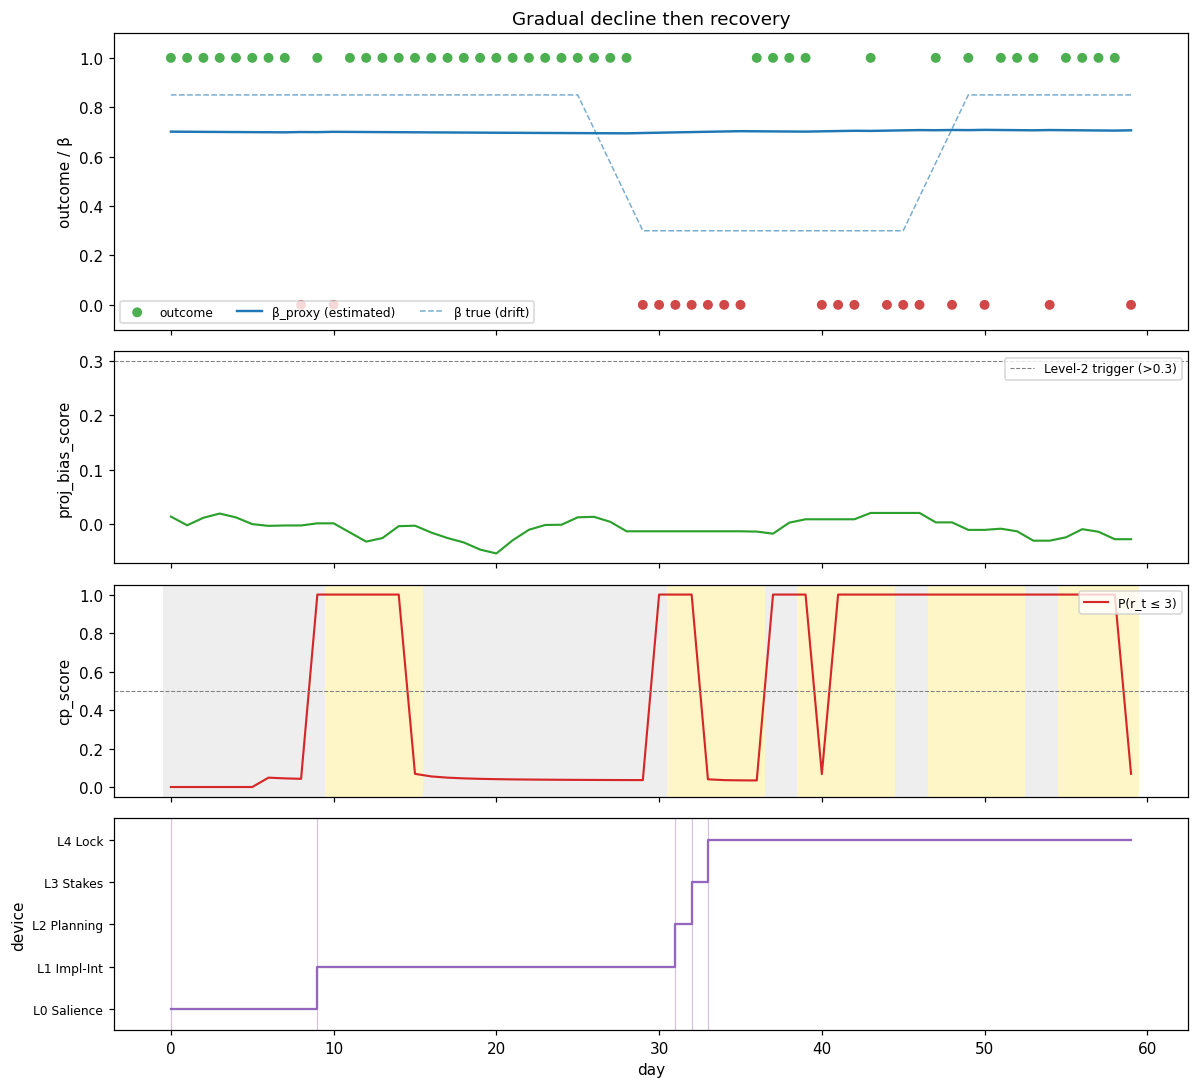

final β_proxy=0.707  proj_bias=-0.028  device=L4 Lock  drift_status=potential
device changes during run: 5


In [7]:
db = reset_db()
user = make_user(db, beta=0.80, email='decline@x.com', current_device=1)

rng = np.random.default_rng(7)
N_DAYS = 60
true_beta = np.concatenate([
    np.full(25, 0.85),
    np.linspace(0.85, 0.30, 5),
    np.full(15, 0.30),
    np.linspace(0.30, 0.85, 5),
    np.full(10, 0.85),
])
rows = []
for d in range(N_DAYS):
    sim_date = date(2026, 1, 2) + timedelta(days=d)
    p = float(true_beta[d])
    completed = 1.0 if rng.random() < p else 0.0
    planned = 60
    actual = int(planned * rng.uniform(0.9, 1.1)) if completed > 0 else None
    rows.append(simulate_day(user, sim_date, completed, planned, actual, db))

plot_trajectory(rows, true_beta, 'Gradual decline then recovery')

## Scenario 3 — Transient dip

True β = 0.85 baseline, with three bad days mid-run. Expected behavior:
- BOCD may briefly flag (`stable → potential`) but classification window
  resolves to `transient` (back to `stable`), no device change.

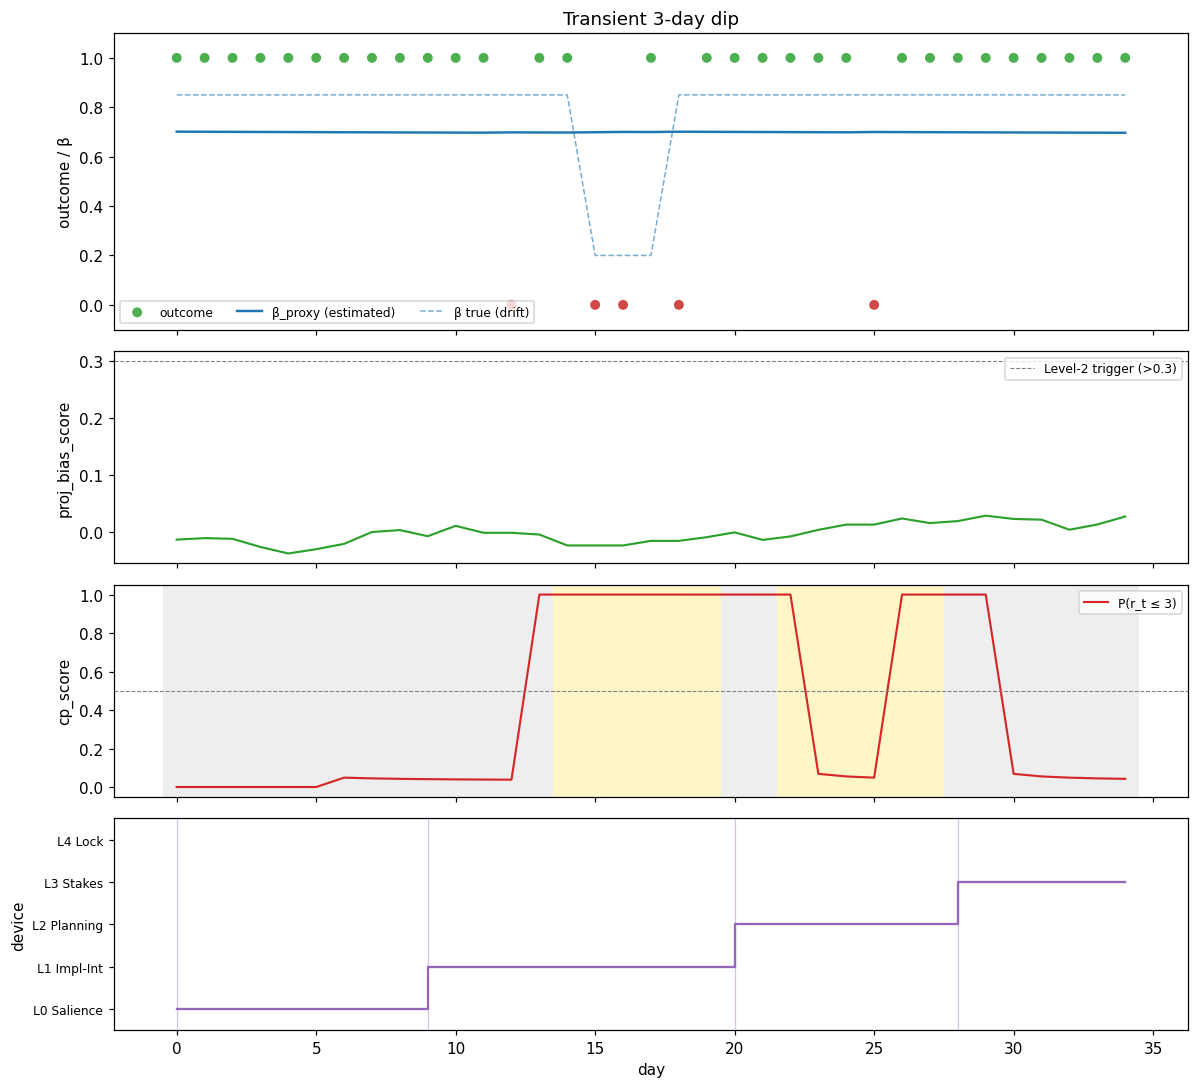

final β_proxy=0.697  proj_bias=0.027  device=L3 Stakes  drift_status=stable
device changes during run: 4


In [8]:
db = reset_db()
user = make_user(db, beta=0.80, email='transient@x.com', current_device=1)

rng = np.random.default_rng(3)
N_DAYS = 35
true_beta = np.full(N_DAYS, 0.85)
true_beta[15:18] = 0.20  # 3-day dip
rows = []
for d in range(N_DAYS):
    sim_date = date(2026, 1, 2) + timedelta(days=d)
    p = float(true_beta[d])
    completed = 1.0 if rng.random() < p else 0.0
    planned = 60
    actual = int(planned * rng.uniform(0.9, 1.1)) if completed > 0 else None
    rows.append(simulate_day(user, sim_date, completed, planned, actual, db))

plot_trajectory(rows, true_beta, 'Transient 3-day dip')

## Scenario 4 — Projection bias dominates

True β = mid-range, but the user systematically under-estimates duration:
actuals run 50–70% over plan. Expected behavior:
- proj_bias_score climbs past 0.3 → recommender returns Level 2 regardless
  of beta.
- BOCD stays stable (completion rate is fine — only durations are off).

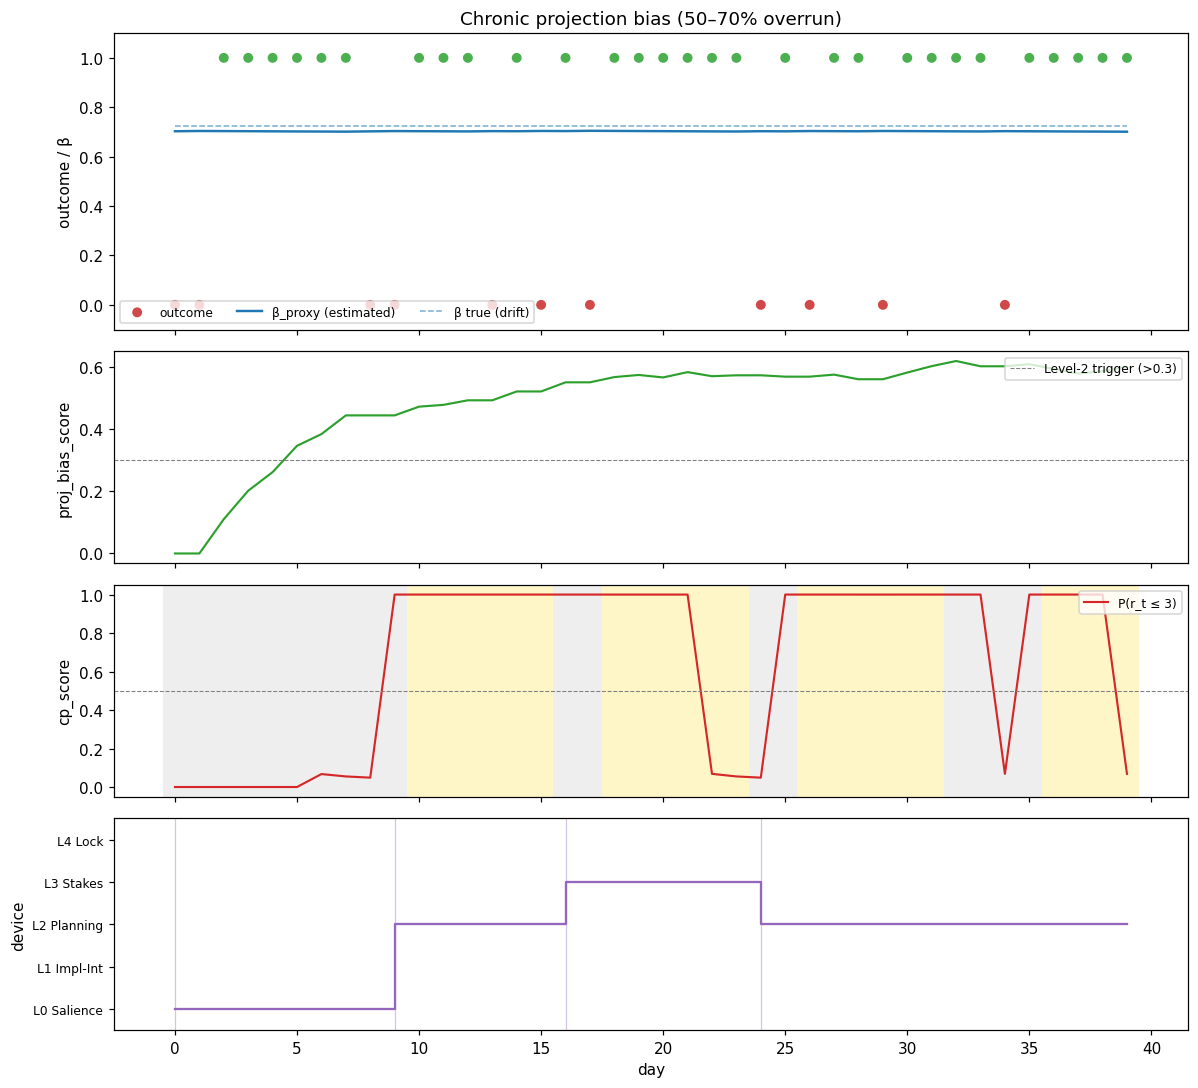

final β_proxy=0.701  proj_bias=0.598  device=L2 Planning  drift_status=potential
device changes during run: 4


In [9]:
db = reset_db()
user = make_user(db, beta=0.70, email='projbias@x.com', current_device=1)

rng = np.random.default_rng(5)
N_DAYS = 40
true_beta = np.full(N_DAYS, mid_user_beta)
rows = []
for d in range(N_DAYS):
    sim_date = date(2026, 1, 2) + timedelta(days=d)
    p = float(true_beta[d])
    completed = 1.0 if rng.random() < p else 0.0
    planned = 60
    actual = int(planned * rng.uniform(1.5, 1.7)) if completed > 0 else None  # heavy overrun
    rows.append(simulate_day(user, sim_date, completed, planned, actual, db))

plot_trajectory(rows, true_beta, 'Chronic projection bias (50–70% overrun)')

## Scenario 5 — Repeated failure escalation

True β at the 10th-percentile value. The recommender's failure-streak
override (≥3 consecutive zeros) should kick the device level up by one
regardless of beta. With low β, this fires repeatedly.

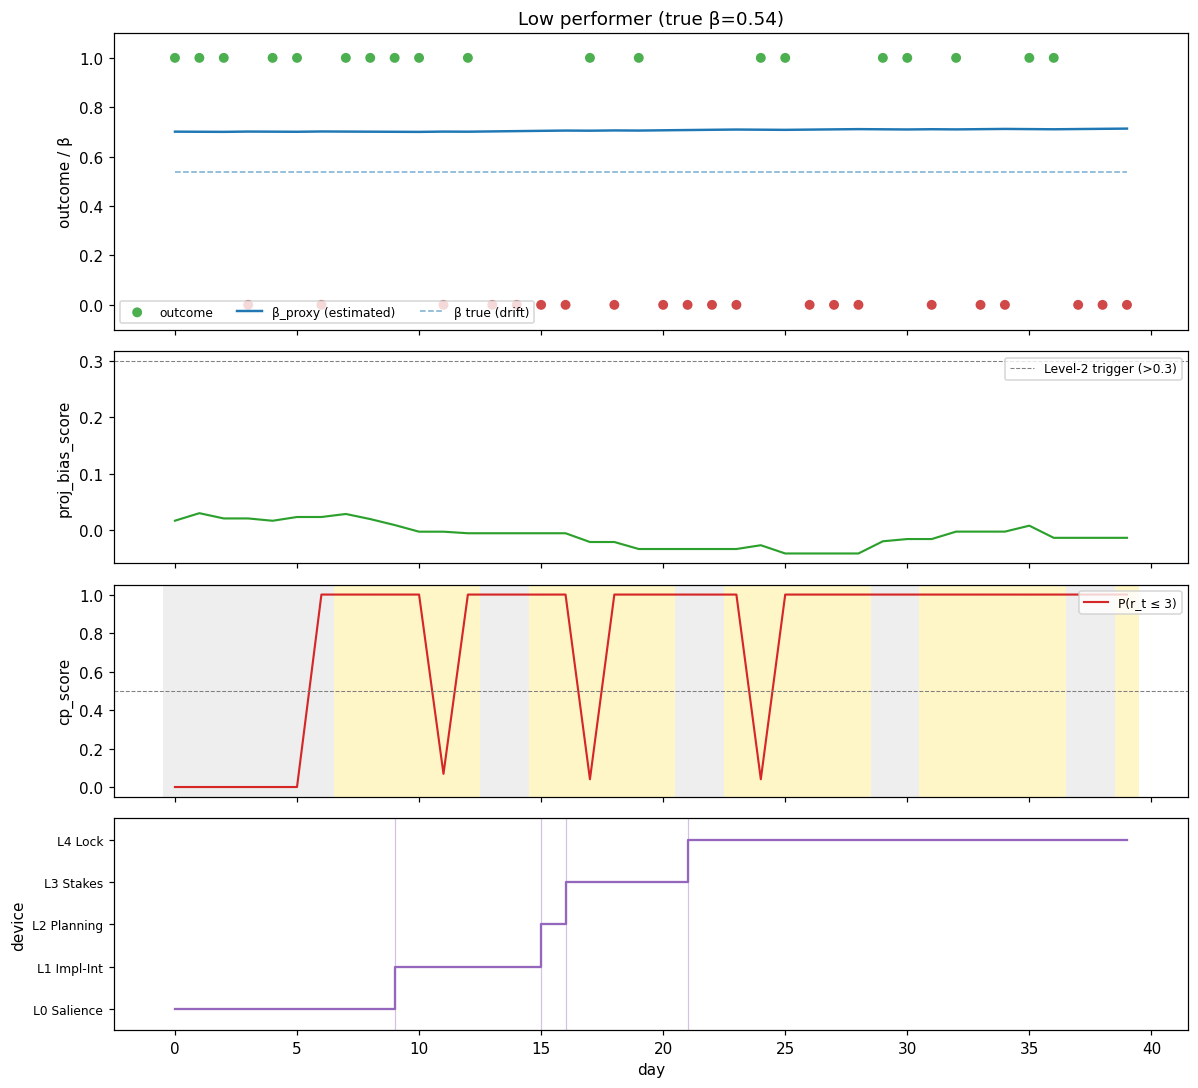

final β_proxy=0.714  proj_bias=-0.014  device=L4 Lock  drift_status=potential
device changes during run: 4


In [10]:
db = reset_db()
user = make_user(db, beta=0.50, email='lowbeta@x.com', current_device=0)

rng = np.random.default_rng(1)
N_DAYS = 40
true_beta = np.full(N_DAYS, low_user_beta)
rows = []
for d in range(N_DAYS):
    sim_date = date(2026, 1, 2) + timedelta(days=d)
    p = float(true_beta[d])
    completed = 1.0 if rng.random() < p else 0.0
    planned = 60
    actual = int(planned * rng.uniform(0.9, 1.1)) if completed > 0 else None
    rows.append(simulate_day(user, sim_date, completed, planned, actual, db))

plot_trajectory(rows, true_beta, f'Low performer (true β={low_user_beta:.2f})')

## Audit-table check

After the last scenario, query the `device_assignments` and `drift_events`
audit tables to confirm the orchestration layer is writing them correctly
(this is what the writeup will draw on for lift / detection metrics).

In [11]:
from sqlalchemy import text

with engine.connect() as conn:
    print('=== device_assignments ===')
    for row in conn.execute(text(
        'SELECT device_type, beta_at_assignment, pre_completion_rate, assigned_at '
        'FROM device_assignments ORDER BY assigned_at'
    )):
        print(row)
    print()
    print('=== drift_events ===')
    for row in conn.execute(text(
        'SELECT drift_type, direction, beta_before, detected_at '
        'FROM drift_events ORDER BY detected_at'
    )):
        print(row)

=== device_assignments ===
(1, 0.7006880640983582, 0.8, '2026-05-05 23:00:12.258968')
(2, 0.7045397758483887, 0.5714285714285714, '2026-05-05 23:00:12.303901')
(3, 0.7056432366371155, 0.5, '2026-05-05 23:00:12.312653')
(4, 0.7077895402908325, 0.42857142857142855, '2026-05-05 23:00:12.350565')

=== drift_events ===
('transient', 'decline', 0.7010617256164551, '2026-05-05 23:00:12.286355')
('level_shift', 'decline', 0.7067431807518005, '2026-05-05 23:00:12.347468')
('level_shift', 'decline', 0.7114552855491638, '2026-05-05 23:00:12.407518')
('transient', 'decline', 0.7108697891235352, '2026-05-05 23:00:12.466783')
